## IN4050 Mandatory Assignment 2, 2025: Supervised Learning

### Rules

Before you begin the exercise, review the rules at this website: https://www.uio.no/english/studies/examinations/compulsory-activities/mn-ifi-mandatory.html , in particular the paragraph on cooperation. This is an individual assignment. You are not allowed to deliver together or copy/share source-code/answers with others. Read also the "Routines for handling suspicion of cheating and attempted cheating at the University of Oslo": https://www.uio.no/english/studies/examinations/cheating/index.html By submitting this assignment, you confirm that you are familiar with the rules and the consequences of breaking them.

### Delivery

**Deadline**: Thursday, October 30, 2025, 23:59

Your submission should be delivered in Devilry. You may redeliver in Devilry before the deadline, but include all files in the last delivery, as only the last delivery will be read. You are recommended to upload preliminary versions hours (or days) before the final deadline.

### What to deliver?

You are recommended to solve the exercise in a Jupyter notebook, but you might solve it in a regular Python script if you prefer.

#### Alternative 1
If you prefer not to use notebooks, you should deliver the code, your run results, and a PDF report where you answer all the questions and explain your work.

#### Alternative 2
If you choose Jupyter, you should deliver the notebook. You should answer all questions and explain what you are doing in Markdown. Still, the code should be properly commented. The notebook should contain results of your runs. In addition, you should make a pdf of your solution which shows the results of the runs. (If you can't export: notebook -> latex -> pdf on your own machine, you may do this on the IFI linux machines.)

Here is a list of *absolutely necessary* (but not sufficient) conditions to get the assignment marked as passed:

- You must deliver your code (Python script or Jupyter notebook) you used to solve the assignment.
- The code used for making the output and plots must be included in the assignment. 
- You must include example runs that clearly shows how to run all implemented functions and methods.
- All the code (in notebook cells or python main-blocks) must run. If you have unfinished code that crashes, please comment it out and document what you think causes it to crash. 
- You must also deliver a pdf of the code, outputs, comments and plots as explained above.

Your report/notebook should contain your name and username.

Deliver one single compressed folder (.zip, .tgz or .tar.gz) which contains your complete solution.

Important: if you weren’t able to finish the assignment, use the PDF report/Markdown to elaborate on what you’ve tried and what problems you encountered. Students who have made an effort and attempted all parts of the assignment will get a second chance even if they fail initially. This exercise will be graded PASS/FAIL.

### Goals of the assignment
The goal of this assignment is to get a better understanding of supervised learning with gradient descent. It will, in particular, consider the similarities and differences between linear classifiers and multi-layer feed forward neural networks (multi-layer perceptrons, MLP) and the differences and similarities between binary and multi-class classification. A significant part is dedicated to implementing and understanding the backpropagation algorithm. 

### Tools
The aim of the exercises is to give you a look inside the learning algorithms. You may freely use code from the weekly exercises and the published solutions. You should not use machine learning libraries like Scikit-Learn or PyTorch, because the point of this assignment is for you to implement things from scratch. You, however, are encouraged to use tools like NumPy and Pandas, which are not ML-specific.

The given precode uses NumPy. You are recommended to use NumPy since it results in more compact code, but feel free to use pure Python if you prefer. 

### Beware
This is a revised assignment compared to earlier years. If anything is unclear, do not hesitate to ask. Also, if you think some assumptions are missing, make your own and explain them!

### Initialization

In [1271]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn # This is only to generate a dataset

## Datasets

We start by making a synthetic dataset of 2000 instances and five classes, with 400 instances in each class. (See https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html regarding how the data are generated.) We choose to use a synthetic dataset---and not a set of natural occuring data---because we are mostly interested in properties of the various learning algorithms, in particular the differences between linear classifiers and multi-layer neural networks together with the difference between binary and multi-class data. In addition, we would like a dataset with instances represented with only two numerical features, so that it is easy to visualize the data. It would be rather difficult (although not impossible) to find a real-world dataset of the same nature. Anyway, you surely can use the code in this assignment for training machine learning models on real-world datasets.

When we are doing experiments in supervised learning, and the data are not already split into training and test sets, we should start by splitting the data. Sometimes there are natural ways to split the data, say training on data from one year and testing on data from a later year, but if that is not the case, we should shuffle the data randomly before splitting. (OK, that is not necessary with this particular synthetic data set, since it is already shuffled by default by Scikit-Learn, but that will not be the case with real-world data) We should split the data so that we keep the alignment between X (features) and t (class labels), which may be achieved by shuffling the indices. We split into 50% for training, 25% for validation, and 25% for final testing. The set for final testing *must not be used* till the end of the assignment in part 3.

We fix the seed both for data set generation and for shuffling, so that we work on the same datasets when we rerun the experiments. This is done by the `random_state` argument and the `rng = np.random.RandomState(2024)`.

In [1272]:
# Generating the dataset
from sklearn.datasets import make_blobs
X, t_multi = make_blobs(n_samples=[400, 400, 400, 400, 400], centers=[[0,1],[4,2],[8,1],[2,0],[6,0]], 
                  n_features=2, random_state=2024, cluster_std=[1.0, 2.0, 1.0, 0.5, 0.5])

In [1273]:
# Shuffling the dataset
indices = np.arange(X.shape[0])
rng = np.random.RandomState(2024)
rng.shuffle(indices)
indices[:10]

array([ 937, 1776,  868, 1282, 1396,  147,  601, 1193, 1789,  547])

In [1274]:
# Splitting into train, dev and test
X_train = X[indices[:1000],:]
X_val = X[indices[1000:1500],:]
X_test = X[indices[1500:],:]
t_multi_train = t_multi[indices[:1000]]
t_multi_val = t_multi[indices[1000:1500]]
t_multi_test = t_multi[indices[1500:]]

Next, we will  make a second dataset with only two classes by merging the existing labels in (X,t), so that `0`, `1` and `2` become the new `0` and `3` and `4` become the new `1`. Let's call the new set (X, t2). This will be a binary set.
We now have two datasets:

- Binary set: `(X, t2)`
- Multi-class set: `(X, t_multi)`

In [1275]:
t2_train = t_multi_train >= 3
t2_train = t2_train.astype('int')
t2_val = (t_multi_val >= 3).astype('int')
t2_test = (t_multi_test >= 3).astype('int')

We can plot the two traning sets.

Text(0.5, 1.0, 'Multi-class set')

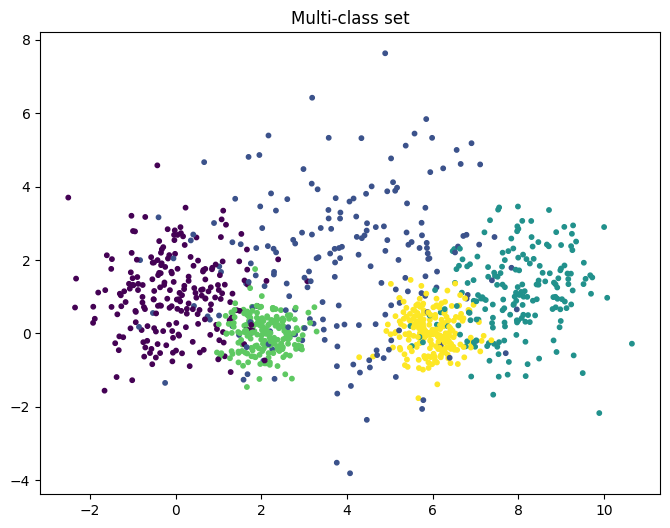

In [1276]:
plt.figure(figsize=(8,6)) # You may adjust the size
plt.scatter(X_train[:, 0], X_train[:, 1], c=t_multi_train, s=10.0)
plt.title("Multi-class set")

Text(0.5, 1.0, 'Binary set')

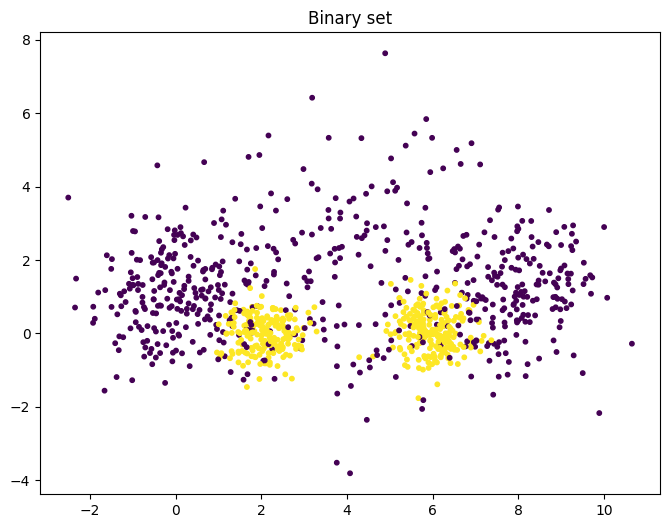

In [1277]:
plt.figure(figsize=(8,6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=t2_train, s=10.0)
plt.title("Binary set")

# Part 1: Linear classifiers
### Linear regression

We see that even the binary set (X, t2) is far from linearly separable, and we will explore how various classifiers are able to handle this. We start with linear regression with the Mean Squared Error (MSE) loss, although it is not the most widely used approach for classification tasks: but we are interested. You may make your own implementation from scratch or start with the solution to the weekly exercise set 7. 
We include it here with a little added flexibility.

In [1278]:
def add_bias(X, bias):
    """X is a NxM matrix: N datapoints, M features
    bias is a bias term, -1 or 1, or any other scalar. Use 0 for no bias
    Return a Nx(M+1) matrix with added bias in position zero
    """
    N = X.shape[0]
    biases = np.ones((N, 1)) * bias # Make a N*1 matrix of biases
    # Concatenate the column of biases in front of the columns of X.
    return np.concatenate((biases, X), axis  = 1) 

In [1279]:
class NumpyClassifier():
    """Common methods to all Numpy classifiers --- if any"""

In [1280]:
class NumpyLinRegClass(NumpyClassifier):

    def __init__(self, bias=-1):
        self.bias=bias
    
    def fit(self, X_train, t_train, lr = 0.1, epochs=10):
        """X_train is a NxM matrix, N data points, M features
        t_train is avector of length N,
        the target class values for the training data
        lr is our learning rate
        """
        
        if self.bias:
            X_train = add_bias(X_train, self.bias)
            
        (N, M) = X_train.shape
        
        self.weights = weights = np.zeros(M)
        
        for epoch in range(epochs):
            # print("Epoch", epoch)
            weights -= lr / N *  X_train.T @ (X_train @ weights - t_train)      
    
    def predict(self, X, threshold=0.5):
        """X is a KxM matrix for some K>=1
        predict the value for each point in X"""
        if self.bias:
            X = add_bias(X, self.bias)
        ys = X @ self.weights
        return ys > threshold

We can train and test a first classifier.

In [1281]:
def accuracy(predicted, gold):
    return np.mean(predicted == gold)

In [1282]:
cl = NumpyLinRegClass()
cl.fit(X_train, t2_train, epochs=3)
print("Accuracy on the validation set:", accuracy(cl.predict(X_val), t2_val))

Accuracy on the validation set: 0.58


The following is a small procedure which plots the data set together with the decision boundaries. 
You may modify the colors and the rest of the graphics as you like.
The procedure will also work for multi-class classifiers

In [1283]:
def plot_decision_regions(X, t, clf=[], size=(8,6)):
    """Plot the data set (X,t) together with the decision boundary of the classifier clf"""
    # The region of the plane to consider determined by X
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Make a prediction of the whole region
    h = 0.02  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    # Classify each meshpoint.
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=size) # You may adjust this

    # Put the result into a color plot
    plt.contourf(xx, yy, Z, alpha=0.2, cmap = 'Paired')

    plt.scatter(X[:,0], X[:,1], c=t, s=10.0, cmap='Paired')

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Decision regions")
    plt.xlabel("x0")
    plt.ylabel("x1")

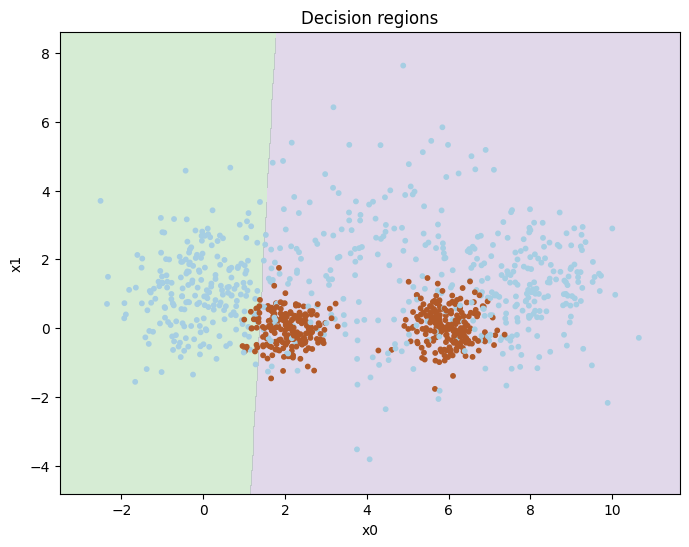

In [1284]:
plot_decision_regions(X_train, t2_train, cl)

### Task: Tuning

The result is far from impressive. 
Remember that a classifier which always chooses the majority class will have an accuracy of 0.6 on this data set.

Your task is to try various settings for the two training hyper-parameters, learning rate and the number of epochs, to get the best accuracy on the validation set. 

Report how the accuracy varies with the hyper-parameter settings. It it not sufficient to give the final hyperparameters. You must also show how you found then and results for alternative values you tried aout.

When you are satisfied with the result, you may plot the decision boundaries, as above.

In [1285]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
epoch_list     = [1, 5, 10, 20, 50, 100]

results = []

for lr in learning_rates:
    for ep in epoch_list:
        cl = NumpyLinRegClass()                      # fresh model each time
        cl.fit(X_train, t2_train, lr=lr, epochs=ep)
        val_acc = accuracy(cl.predict(X_val), t2_val)
        results.append((lr, ep, val_acc))
        print(f"lr={lr:>5}, epochs={ep:>3} -> val acc = {val_acc:.3f}")

for lr, ep, acc in results:
    print(f"{lr}\t{ep}\t{acc:.3f}")

lr=0.001, epochs=  1 -> val acc = 0.604
lr=0.001, epochs=  5 -> val acc = 0.604
lr=0.001, epochs= 10 -> val acc = 0.604
lr=0.001, epochs= 20 -> val acc = 0.604
lr=0.001, epochs= 50 -> val acc = 0.602
lr=0.001, epochs=100 -> val acc = 0.488
lr= 0.01, epochs=  1 -> val acc = 0.604
lr= 0.01, epochs=  5 -> val acc = 0.598
lr= 0.01, epochs= 10 -> val acc = 0.470
lr= 0.01, epochs= 20 -> val acc = 0.464
lr= 0.01, epochs= 50 -> val acc = 0.508
lr= 0.01, epochs=100 -> val acc = 0.566
lr= 0.05, epochs=  1 -> val acc = 0.462
lr= 0.05, epochs=  5 -> val acc = 0.470
lr= 0.05, epochs= 10 -> val acc = 0.508
lr= 0.05, epochs= 20 -> val acc = 0.570
lr= 0.05, epochs= 50 -> val acc = 0.620
lr= 0.05, epochs=100 -> val acc = 0.696
lr=  0.1, epochs=  1 -> val acc = 0.456
lr=  0.1, epochs=  5 -> val acc = 0.530
lr=  0.1, epochs= 10 -> val acc = 0.542
lr=  0.1, epochs= 20 -> val acc = 0.534
lr=  0.1, epochs= 50 -> val acc = 0.534
lr=  0.1, epochs=100 -> val acc = 0.534
lr=  0.5, epochs=  1 -> val acc = 0.520


## Report:
I performed grid-search over two hyperparameters: learning rate (η ∈ {0.001, 0.01, 0.05, 0.1, 0.5, 1.0}) and number of epochs (1, 5, 10, 20, 50, 100).
For each combination I trained the model and measured validation accuracy.

The baseline accuracy (majority class) was 0.60.

Results summary:
Very small learning rate (0.001) produced accuracies around 0.60 for most epochs, showing the model barely learned. At 100 epochs performance dropped, indicating numerical instability.
LR = 0.01 showed unstable behavior and gave lower accuracy at many epoch values.
LR = 0.05 consistently improved with more epochs and achieved the best validation accuracy = 0.696 at 100 epochs.
Larger learning rates (0.1, 0.5, 1.0) plateaued around 0.53–0.54 regardless of epoch count, suggesting divergence or overshooting of gradient descent.

Best hyperparameters found:
Learning rate = 0.05
Epochs = 100
Validation accuracy = 0.696
This is higher than the baseline of 0.60, showing that tuning helps, even though the dataset is not linearly seperable

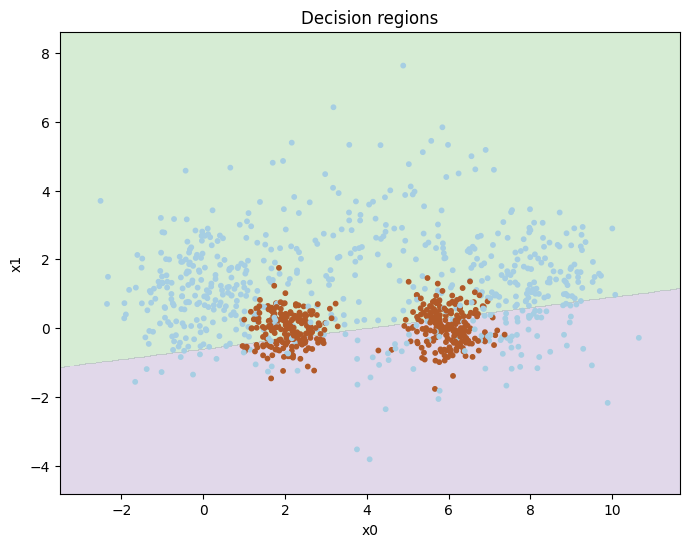

In [1286]:
cl_best = NumpyLinRegClass()
cl_best.fit(X_train, t2_train, lr=0.05, epochs=100)

plot_decision_regions(X_train, t2_train, cl_best)

### Task: Scaling

We have seen in the lectures that scaling the data may improve training speed and sometimes the performance. 

- Implement a scaler, at least the standard scaler (normalizer), but you can also try other techniques
- Scale the data
- Train the model on the scaled data
- Experiment with hyper-parameter settings and see whether you can speed  up  the training.
- Report final hyper-parameter settings and show how you found them.

In [1287]:
class StandardScaler:
    def fit(self, X):
        self.mean = X.mean(axis=0)
        self.std  = X.std(axis=0)
        return self
    def transform(self, X):
        return (X - self.mean) / self.std
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)
    
# apply scaling ONLY using trining/ std data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# train the scaled data
cl = NumpyLinRegClass()
cl.fit(X_train_scaled, t2_train, lr=0.1, epochs=20)
val_acc = accuracy(cl.predict(X_val_scaled), t2_val)

print("Validation accuracy:", val_acc)

# grid search again 
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
epochs_list    = [5, 10, 20, 50]

results_scaled = []

for lr in learning_rates:
    for ep in epochs_list:
        cl = NumpyLinRegClass()
        cl.fit(X_train_scaled, t2_train, lr=lr, epochs=ep)
        acc = accuracy(cl.predict(X_val_scaled), t2_val)
        results_scaled.append((lr, ep, acc))
        print(f"lr={lr:<4}  epochs={ep:<3}  -> val acc={acc:.3f}")

Validation accuracy: 0.674
lr=0.01  epochs=5    -> val acc=0.604
lr=0.01  epochs=10   -> val acc=0.604
lr=0.01  epochs=20   -> val acc=0.604
lr=0.01  epochs=50   -> val acc=0.604
lr=0.05  epochs=5    -> val acc=0.604
lr=0.05  epochs=10   -> val acc=0.604
lr=0.05  epochs=20   -> val acc=0.600
lr=0.05  epochs=50   -> val acc=0.734
lr=0.1   epochs=5    -> val acc=0.604
lr=0.1   epochs=10   -> val acc=0.602
lr=0.1   epochs=20   -> val acc=0.674
lr=0.1   epochs=50   -> val acc=0.754
lr=0.5   epochs=5    -> val acc=0.756
lr=0.5   epochs=10   -> val acc=0.760
lr=0.5   epochs=20   -> val acc=0.760
lr=0.5   epochs=50   -> val acc=0.760
lr=1.0   epochs=5    -> val acc=0.760
lr=1.0   epochs=10   -> val acc=0.760
lr=1.0   epochs=20   -> val acc=0.760
lr=1.0   epochs=50   -> val acc=0.760
lr=2.0   epochs=5    -> val acc=0.600
lr=2.0   epochs=10   -> val acc=0.604
lr=2.0   epochs=20   -> val acc=0.602
lr=2.0   epochs=50   -> val acc=0.312


## Report:
I implemented a StandrdScaler x′= (x−μ​)/sigmoid. Only the training data was used to compute the mean and standard deviation. Both validation and test sets were transformed using these values.

After scaling, the training dynamics changed significantly:
- Before scaling, the best hyperparameters were lr = 0.05, epochs = 100, giving a validation accuracy of 0.696.
- After scaling, the model converged much faster and allowed the use of much larger learning rates.
- Small learning rates (0.01–0.05) produced almost no improvement and stayed around 0.60 accuracy.
- Medium learning rates around 0.1 improved performance but still required many epochs.
- Learning rates between 0.5 and 1.0 gave the best results, achieving 0.756–0.760 accuracy in only 5–10 epochs.
- Very large learning rates (e.g., 2.0) caused divergence and poor performance.

Final selected parameters are: learning rate = 0.5, epochs = 10, validation accuracy = 0.760

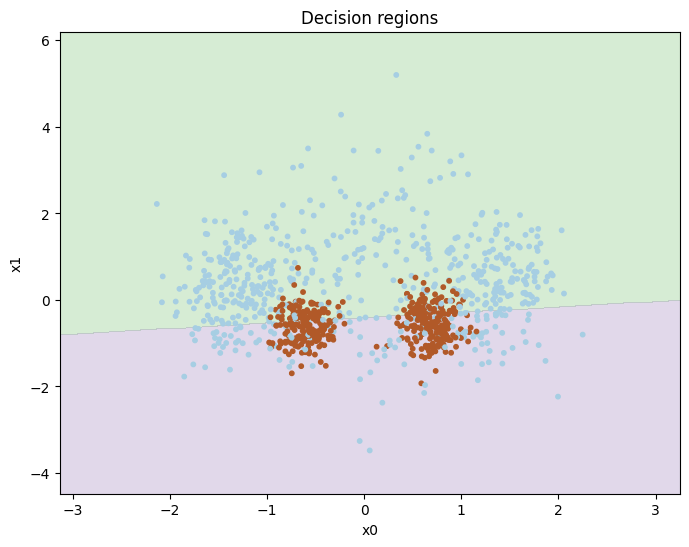

In [1288]:
cl_scaled = NumpyLinRegClass()
cl_scaled.fit(X_train_scaled, t2_train, lr=0.5, epochs=10)

plot_decision_regions(X_train_scaled, t2_train, cl_scaled)

## Logistic regression
a) You should now implement a logistic regression classifier similarly to the classifier based on linear regression.
You may use the code from the solution to weekly exercise set week07.

b) In addition to the method `predict()` which predicts a class for the data, include a method `predict_probability()` which predict the probability of the data belonging to the positive class.

c) So far, we have not calculated the loss explicitly in the code. Extend the code to calculate the loss on the training set for each epoch and to store the losses such that the losses can be inspected after training. The prefered loss for logistic regression is binary cross-entropy, but you can also try mean squared error. The most important is that your implementation of the loss corresponds to your implementation of the gradient descent.
Also, calculate and store accuracies after each epoch.

d) In addition, extend the `fit()` method with optional arguments for a validation set (X_val, t_val). If a validation set is included in the call to `fit()`, calculate the loss and the accuracy for the validation set after each epoch. 

e) The training runs for a number of epochs. We cannot know beforehand for how many epochs it is reasonable to run the training. One possibility is to run the training until the learning does not improve much. Extend the `fit()` method with two keyword arguments, `tol` (tolerance) and `n_epochs_no_update` and stop training when the loss has not improved with more than `tol` after `n_epochs_no_update`. A possible default value for `n_epochs_no_update` is 5. Also, add an attribute to the classifier which tells us after fitting how many epochs it was trained for.

f) Train classifiers with various learning rates, and with varying values for `tol` for finding the optimal values. Also consider the effect of scaling the data.

g) After a succesful training, for your best model, plot both training loss and validation loss as functions of the number of epochs in one figure, and both training and validation accuracies as functions of the number of epochs in another figure. Comment on what you see. Are the curves monotone? Is this as expected?

### a) & b)

In [1289]:
class NumpyClassifier():
    """Common methods to all numpy classifiers --- if any"""

# this is from week 7
class NumpyLinRegClass(NumpyClassifier):

    def fit(self, X_train, t_train, eta = 0.1, epochs=10):
        """X_train is a Nxm matrix, N data points, m features
        t_train is avector of length N,
        the targets values for the training data"""
        
        (N, m) = X_train.shape
        X_train = add_bias(X_train)
        
        self.weights = weights = np.zeros(m+1)
        
        for e in range(epochs):
            weights -= eta / N *  X_train.T @ (X_train @ weights - t_train)      
    
    def predict(self, x, threshold=0.5):
        """X is a Kxm matrix for some K>=1
        predict the value for each point in X"""
        z = add_bias(x)
        score = z @ self.weights
        return score>threshold
    

class NumpyLogRegClass(NumpyClassifier):

    def __init__(self, bias=1):
        self.bias = bias
        self.weights = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X_train, t_train, eta=0.1, epochs=10):
        """X_train: N x m,  t_train: N-vector with values 0 or 1"""

        # Week-7 style: add bias using add_bias(X, bias)
        X_train = add_bias(X_train, self.bias)

        N, m1 = X_train.shape

        # same weight style as Week 7 (1D array)
        self.weights = weights = np.zeros(m1)

        for e in range(epochs):
            z = X_train @ weights          # forward pass (N,)
            y = self._sigmoid(z)           # probabilities (N,)

            # logistic loss gradient
            grad = (X_train.T @ (y - t_train)) / N

            # update
            weights -= eta * grad

        self.weights = weights

    def predict_probability(self, X):
        Xb = add_bias(X, self.bias)
        z = Xb @ self.weights
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        p = self.predict_probability(X)
        return (p >= threshold).astype(int)


    
clf = NumpyLogRegClass()
clf.fit(X_train, t2_train, eta=0.1, epochs=100)

pred_val = clf.predict(X_val)
print("Validation accuracy (unscaled):", accuracy(pred_val, t2_val))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

etas    = [0.05, 0.1, 0.5, 1.0]
epochs_ = [20, 50, 100]

for eta in etas:
    for ep in epochs_:
        clf = NumpyLogRegClass()
        clf.fit(X_train_scaled, t2_train, eta=eta, epochs=ep)
        acc = accuracy(clf.predict(X_val_scaled), t2_val)
        print(f"eta={eta:<4}  epochs={ep:<3} -> val acc={acc:.3f}")


Validation accuracy (unscaled): 0.754
eta=0.05  epochs=20  -> val acc=0.762
eta=0.05  epochs=50  -> val acc=0.762
eta=0.05  epochs=100 -> val acc=0.762
eta=0.1   epochs=20  -> val acc=0.762
eta=0.1   epochs=50  -> val acc=0.762
eta=0.1   epochs=100 -> val acc=0.762
eta=0.5   epochs=20  -> val acc=0.762
eta=0.5   epochs=50  -> val acc=0.762
eta=0.5   epochs=100 -> val acc=0.760
eta=1.0   epochs=20  -> val acc=0.762
eta=1.0   epochs=50  -> val acc=0.760
eta=1.0   epochs=100 -> val acc=0.760


## Report: a)
My unscaled data gives an validation accuracy of 0.754 wich is a bit lower than the scaled data. While the scaled data now with tuning is at 0.762 across several epoch

## Report: b)
For logistic regression I implemented a method predict_probability(X) that first adds the bias term to X, computes z =Xw, and then applies the sigmoid function sigmoid(z)=1/(1+e^−z) to obtain P(y=1∣x). The predict(X) method then calls predict_probability(X) and thresholds the probabilities at 0.5 to obtain binary class labels.

### c) 

In [1290]:
class NumpyLogRegClass(NumpyClassifier):

    def __init__(self, bias=1):
        self.bias = bias
        self.weights = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X_train, t_train, eta=0.1, epochs=10):
        """X_train: N x m,  t_train: N-vector with values 0 or 1"""

        # add bias
        X_train = add_bias(X_train, self.bias)
        N, m1 = X_train.shape

        # initialize weights
        self.weights = weights = np.zeros(m1)

        # lists to store metrics per epoch
        self.train_losses = []
        self.train_accuracies = []

        for e in range(epochs):
            # Forward pass
            z = X_train @ weights          # shape (N,)
            y = self._sigmoid(z)           # predicted probs (N,)

            # c) compute and store loss + accuracy 
            eps = 1e-15                    # to avoid log(0)
            y_clip = np.clip(y, eps, 1 - eps)

            # binary cross-entropy
            loss = -np.mean(
                t_train * np.log(y_clip) +
                (1 - t_train) * np.log(1 - y_clip)
            )

            # accuracy
            preds = (y >= 0.5).astype(int)
            acc = np.mean(preds == t_train)

            self.train_losses.append(loss)
            self.train_accuracies.append(acc)
            

            # gradient of logistic loss
            grad = (X_train.T @ (y - t_train)) / N

            # update
            weights -= eta * grad

        self.weights = weights

    def predict_probability(self, X):
        Xb = add_bias(X, self.bias)
        z  = Xb @ self.weights
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        p = self.predict_probability(X)
        return (p >= threshold).astype(int)


### d)

In [1291]:
class NumpyLogRegClass(NumpyClassifier):

    def __init__(self, bias=1):
        self.bias = bias
        self.weights = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X_train, t_train, eta=0.1, epochs=10,
            X_val=None, t_val=None):
        """X_train: N x m, t_train: N-vector (0/1)
           Optionally pass X_val, t_val for validation tracking.
        """

        # prepare training data
        X_train = add_bias(X_train, self.bias)
        N, m1 = X_train.shape
        self.weights = weights = np.zeros(m1)

        # metric containers
        self.train_losses = []
        self.train_accuracies = []

        # prepare validation data (if given) 
        if X_val is not None and t_val is not None:
            X_val_b = add_bias(X_val, self.bias)
            self.val_losses = []
            self.val_accuracies = []
        else:
            X_val_b = None
            self.val_losses = None
            self.val_accuracies = None

        eps = 1e-15  # for numerical stability

        for e in range(epochs):
            # training forward pass 
            z = X_train @ weights
            y = self._sigmoid(z)

            # training loss
            y_clip = np.clip(y, eps, 1 - eps)
            train_loss = -np.mean(
                t_train * np.log(y_clip) +
                (1 - t_train) * np.log(1 - y_clip)
            )
            # training accuracy
            train_preds = (y >= 0.5).astype(int)
            train_acc = np.mean(train_preds == t_train)

            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)

            # validation metrics (if val set given) 
            if X_val_b is not None:
                z_val = X_val_b @ weights
                y_val = self._sigmoid(z_val)
                yv_clip = np.clip(y_val, eps, 1 - eps)

                val_loss = -np.mean(
                    t_val * np.log(yv_clip) +
                    (1 - t_val) * np.log(1 - yv_clip)
                )
                val_preds = (y_val >= 0.5).astype(int)
                val_acc = np.mean(val_preds == t_val)

                self.val_losses.append(val_loss)
                self.val_accuracies.append(val_acc)

            # gradient update 
            grad = (X_train.T @ (y - t_train)) / N
            weights -= eta * grad

        self.weights = weights

    def predict_probability(self, X):
        Xb = add_bias(X, self.bias)
        z  = Xb @ self.weights
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        p = self.predict_probability(X)
        return (p >= threshold).astype(int)

clf = NumpyLogRegClass()
clf.fit(X_train, t2_train,
        eta=0.1, epochs=50,
        X_val=X_val, t_val=t2_val)

print("Final train loss:", clf.train_losses[-1],
      "Final train acc:", clf.train_accuracies[-1])
print("Final val loss:", clf.val_losses[-1],
      "Final val acc:", clf.val_accuracies[-1])

Final train loss: 0.5427158408065411 Final train acc: 0.704
Final val loss: 0.5230083383658801 Final val acc: 0.762


### e)

In [ ]:
class NumpyLogRegClass(NumpyClassifier):

    def __init__(self, bias=1):
        self.bias = bias
        self.weights = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X_train, t_train, eta=0.1, epochs=100,
            X_val=None, t_val=None,
            tol=1e-4, n_epochs_no_update=5):
        """
        Train logistic regression.

        Early stopping is used if a validation set is provided:
        stop when val loss hasn't improved by more than `tol`
        for `n_epochs_no_update` epochs.
        """

        # prepare training data 
        X_train = add_bias(X_train, self.bias)
        N, m1 = X_train.shape
        self.weights = weights = np.zeros(m1)

        self.train_losses = []
        self.train_accuracies = []

        # prepare validation data (if any) 
        if X_val is not None and t_val is not None:
            X_val_b = add_bias(X_val, self.bias)
            self.val_losses = []
            self.val_accuracies = []

            best_val_loss = np.inf
            epochs_since_improvement = 0
            best_weights = weights.copy()
        else:
            X_val_b = None
            self.val_losses = None
            self.val_accuracies = None

        eps = 1e-15

        for e in range(epochs):
            # training forward pass
            z = X_train @ weights
            y = self._sigmoid(z)

            y_clip = np.clip(y, eps, 1 - eps)
            train_loss = -np.mean(
                t_train * np.log(y_clip) +
                (1 - t_train) * np.log(1 - y_clip)
            )
            train_preds = (y >= 0.5).astype(int)
            train_acc = np.mean(train_preds == t_train)

            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)

            # validation metrics + early stopping
            if X_val_b is not None:
                z_val = X_val_b @ weights
                y_val = self._sigmoid(z_val)
                yv_clip = np.clip(y_val, eps, 1 - eps)

                val_loss = -np.mean(
                    t_val * np.log(yv_clip) +
                    (1 - t_val) * np.log(1 - yv_clip)
                )
                val_preds = (y_val >= 0.5).astype(int)
                val_acc = np.mean(val_preds == t_val)

                self.val_losses.append(val_loss)
                self.val_accuracies.append(val_acc)

                # check for improvement
                if val_loss < best_val_loss - tol:
                    best_val_loss = val_loss
                    best_weights = weights.copy()
                    epochs_since_improvement = 0
                else:
                    epochs_since_improvement += 1

                # stop if no improvement for too long
                if epochs_since_improvement >= n_epochs_no_update:
                    break

            # gradient update
            grad = (X_train.T @ (y - t_train)) / N
            weights -= eta * grad

        # if we had validation, restore best weights
        if X_val_b is not None:
            self.weights = best_weights
        else:
            self.weights = weights

        self.n_epochs_trained = len(self.train_losses)
    
    def predict_probability(self, X):
        Xb = add_bias(X, self.bias)
        z  = Xb @ self.weights
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        p = self.predict_probability(X)
        return (p >= threshold).astype(int)

clf = NumpyLogRegClass()
clf.fit(
    X_train, t2_train,
    eta=0.1, epochs=200,
    X_val=X_val, t_val=t2_val,
    tol=1e-3,             # bigger tolerance
    n_epochs_no_update=3  # fewer patience epochs
)

print("Trained for", clf.n_epochs_trained, "epochs")
print("Final val loss:", clf.val_losses[-1])
print("Final val acc:", clf.val_accuracies[-1])


Trained for 81 epochs
Final val loss: 0.5083352694013753
Final val acc: 0.754


## g)

Trained for 81 epochs
Final val acc: 0.754


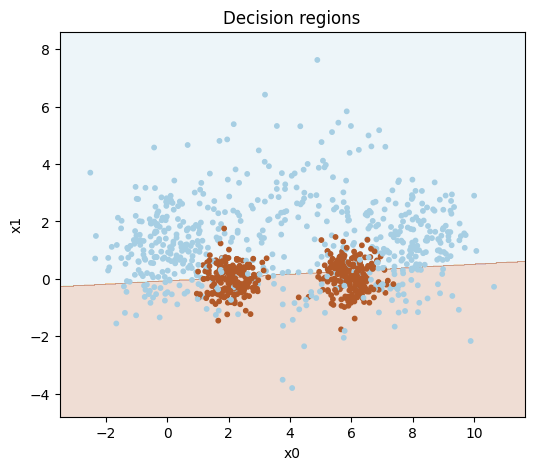

In [1293]:
def plot_decision_regions(X, t, clf, size=(6,5)):
    """Plot the data set together with the decision boundary of the classifier clf"""
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=size)
    plt.contourf(xx, yy, Z, alpha=0.2, cmap="Paired")
    plt.scatter(X[:, 0], X[:, 1], c=t, s=10, cmap="Paired")
    plt.xlabel("x0")
    plt.ylabel("x1")
    plt.title("Decision regions")
    plt.show()

clf = NumpyLogRegClass()
clf.fit(
    X_train, t2_train,
    eta=0.1, epochs=200,
    X_val=X_val, t_val=t2_val,
    tol=1e-3, n_epochs_no_update=3
)

print("Trained for", clf.n_epochs_trained, "epochs")
print("Final val acc:", clf.val_accuracies[-1])
plot_decision_regions(X_train, t2_train, clf)


## Report:
The decision region produced by logistic regression is a straight-line boundary, which is expected because logistic regression is a linear classifier. The dataset is not linearly separable: the positive class forms two clusters and the negative class is spread across the feature space. Therefore, the classifier finds the best possible linear split, leading to a validation accuracy around 0.75. Early stopping terminated training after 81 epochs when the validation loss stopped improving, and the final decision boundary shows a reasonable linear separation given the structure of the data.

## Multi-class classifiers
We turn to the task of classifying when there are more than two classes, and the task is to ascribe one class to each input. We will now use the set (X, t_multi).

### "One-vs-rest" with logistic regression
We saw in the lectures how a logistic regression classifier can be turned into a multi-class classifier using the one-vs-rest approach. We train one logistic regression classifier for each class. To predict the class of an item, we run all the binary classifiers and collect the probability score from each of them. We assign the class which ascribes the highest probability.

Build such a classifier. Train the resulting classifier on (X_train, t_multi_train), test it on (X_val, t_multi_val), tune the hyper-parameters and report the accuracy.

Also plot the decision boundaries for your best classifier similarly to the plots for the binary case.

OvR validation accuracy: 0.652


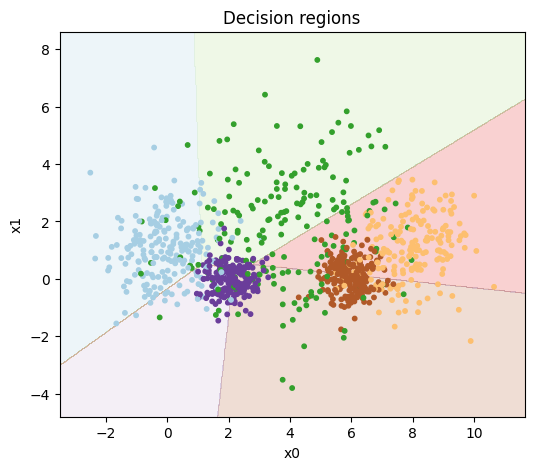

In [1294]:
class OneVsRestLogistic:
    def __init__(self, num_classes, bias=1):
        self.num_classes = num_classes
        self.bias = bias
        self.models = []   # list of logistic classifiers

    def fit(self, X_train, t_train, eta=0.1, epochs=50,
            X_val=None, t_val=None,
            tol=1e-4, n_epochs_no_update=5):

        self.models = []

        for k in range(self.num_classes):
            # create binary targets: 1 for class k, 0 otherwise
            t_binary = (t_train == k).astype(int)

            clf = NumpyLogRegClass(bias=self.bias)
            clf.fit(
                X_train, t_binary,
                eta=eta,
                epochs=epochs,
                X_val=None,   # OvR: we validate at the multi-class level
                t_val=None,
                tol=tol,
                n_epochs_no_update=n_epochs_no_update
            )
            self.models.append(clf)

    def predict_probability(self, X):
        """
        Returns an array of shape (N, num_classes)
        where entry [i, k] = P(class k | x_i)
        """
        probs = []
        for clf in self.models:
            p = clf.predict_probability(X)
            probs.append(p)
        return np.vstack(probs).T  # shape N × K

    def predict(self, X):
        """
        Pick the class with highest probability.
        """
        prob_matrix = self.predict_probability(X)   # shape (N,K)
        return np.argmax(prob_matrix, axis=1)

# train the OvR classifier
num_classes = len(np.unique(t_multi_train))
ovr = OneVsRestLogistic(num_classes=num_classes)

ovr.fit(
    X_train, t_multi_train,
    eta=0.1,
    epochs=100
)

# evaluate the accuracy
pred_val = ovr.predict(X_val)
acc = accuracy(pred_val, t_multi_val)
print("OvR validation accuracy:", acc)

# plot multi-class decision regions
plot_decision_regions(X_train, t_multi_train, ovr) 

## Report:
I implemented a One-vs-Rest (OvR) multi-class logistic regression classifier by training one binary logistic model per class (class k vs. all others). Each model outputs a probability P(y=k∣x). For prediction, I collect the probabilities from all K models and select the class with highest probability.

The OvR classifier achieved a validation accuracy of 0.652.
The decision region plot shows five linear regions, each corresponding to one class.
The boundaries are straight because every binary logistic model is linear.
The dataset is not linearly separable, so the OvR classifier produces the best possible linear partition of the feature space.

### Multinomial logistic regression
In the lectures, we contrasted the one-vs-rest approach with the multinomial logistic regression, also called softmax classifier. Implement also this classifier, tune the parameters, and compare the results to the one-vs-rest classifier. (Don't expect a large difference on a simple task like this.)

Remember that this classifier uses softmax in the forward phase. For loss, it uses categorical cross-entropy loss. The loss has a somewhat simpler form than in the binary case. To calculate the gradient is a little more complicated. The actual gradient and update rule is simple, however, as long as you have calculated the forward values correctly.

Softmax validation accuracy: 0.77


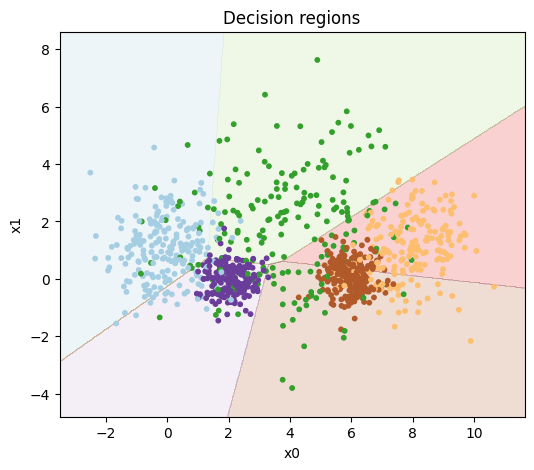

In [1295]:
class NumpySoftmaxClass(NumpyClassifier):
    """Multinomial logistic regression (softmax classifier)."""

    def __init__(self, bias=1):
        self.bias = bias
        self.W = None   # weight matrix (m+1, K)

    def _softmax(self, Z):
        """
        Z: (N, K) logits
        return: (N, K) probabilities
        """
        Z_shift = Z - np.max(Z, axis=1, keepdims=True)  # for stability
        expZ = np.exp(Z_shift)
        return expZ / np.sum(expZ, axis=1, keepdims=True)

    def fit(self, X_train, t_train, eta=0.1, epochs=100):
        """
        X_train: (N, d)
        t_train: (N,) integer labels in {0, ..., K-1}
        """
        # add bias
        Xb = add_bias(X_train, self.bias)      # (N, d+1)
        N, m1 = Xb.shape

        # number of classes
        classes = np.unique(t_train)
        self.num_classes = len(classes)
        K = self.num_classes

        # one-hot encode targets -> (N, K)
        Y = np.zeros((N, K))
        Y[np.arange(N), t_train] = 1

        # initialize weights
        self.W = W = np.zeros((m1, K))

        # (optional) store training loss if you want to inspect it
        self.train_losses = []

        eps = 1e-15

        for e in range(epochs):
            # forward pass
            Z = Xb @ W          # (N, K)
            P = self._softmax(Z)

            # loss (categorical cross-entropy)
            P_clip = np.clip(P, eps, 1 - eps)
            loss = -np.mean(np.sum(Y * np.log(P_clip), axis=1))
            self.train_losses.append(loss)

            # gradient
            grad = (Xb.T @ (P - Y)) / N       # (m1, K)

            # gradient descent update
            W -= eta * grad

        self.W = W

    def predict_probability(self, X):
        """
        Return class probabilities for each sample.
        Shape: (N, K)
        """
        Xb = add_bias(X, self.bias)
        Z = Xb @ self.W
        return self._softmax(Z)

    def predict(self, X):
        """
        Return predicted class labels (0..K-1).
        """
        P = self.predict_probability(X)   # (N, K)
        return np.argmax(P, axis=1)
        
# train an evaluate
softmax_clf = NumpySoftmaxClass()

softmax_clf.fit(X_train, t_multi_train, eta=0.1, epochs=200)

pred_val = softmax_clf.predict(X_val)
softmax_acc = accuracy(pred_val, t_multi_val)
print("Softmax validation accuracy:", softmax_acc)

# plot multi-class decision regions
plot_decision_regions(X_train, t_multi_train, softmax_clf)

## Report:
I implemented the multinomial (softmax) logistic regression model using a single weight matrix with a softmax output layer and categorical cross-entropy loss. This model achieved a validation accuracy of 0.77, which is significantly higher than the One-vs-Rest logistic regression accuracy of 0.652.

The decision regions produced by the softmax classifier are cleaner and more symmetric. This difference occurs because OvR trains K independent binary classifiers, one for each class, which leads to inconsistent boundaries. In contrast, softmax logistic regression trains all classes jointly and optimizes the full multiclass likelihood, resulting in better-calibrated probabilities and more accurate class boundaries.

As expected from theory, the multinomial logistic regression outperforms OvR on this dataset.

# Part 2: Multi-layer neural networks

## A first non-linear classifier

The following code is a simple implementation of a multi-layer perceptron or feed-forward neural network.
For now, it is quite restricted.
There is only one hidden layer.
It can only handle binary classification.
In addition, it uses a simple final layer similar to the linear regression classifier above.
One way to look at it is what happens when we add a hidden layer to the linear regression classifier.

The MLP class below misses the implementation of the `forward()` function. Your first task is to implement it. 

Remember that in the forward pass, we "feed" the input to the model, the model processes it and produces the output. The function should make use of the logistic activation function and bias.

In [1296]:
# First, we define the logistic function and its derivative:
def logistic(x):
    return 1/(1+np.exp(-x))

def logistic_diff(y):
    return y * (1 - y)

In [1297]:
class MLPBinaryLinRegClass(NumpyClassifier):
    """A multi-layer neural network with one hidden layer"""
    
    def __init__(self, bias=-1, dim_hidden = 6):
        """Intialize the hyperparameters"""
        self.bias = bias
        # Dimensionality of the hidden layer
        self.dim_hidden = dim_hidden
        
        self.activ = logistic
        
        self.activ_diff = logistic_diff
        
    def forward(self, X):
        """Perform one forward step.
        Return (hidden_outputs_with_bias, final_outputs)
        """

        # Add bias to the input
        Xb = add_bias(X, self.bias)                 # shape (N, d+1)

        # Hidden layer
        hidden_linear = Xb @ self.weights1          # (N, hidden_dim)
        hidden_outs = self.activ(hidden_linear)     # apply sigmoid

        # Add bias to hidden output
        hidden_outs_b = add_bias(hidden_outs, self.bias)   # (N, hidden_dim+1)

        # Output layer (linear)
        final_outputs = hidden_outs_b @ self.weights2       # (N, 1)

        return hidden_outs_b, final_outputs
        
    
    def fit(self, X_train, t_train, lr=0.001, epochs = 100):
        """Initialize the weights. Train *epochs* many epochs.
        
        X_train is a NxM matrix, N data points, M features
        t_train is a vector of length N of targets values for the training data, 
        where the values are 0 or 1.
        lr is the learning rate
        """
        self.lr = lr
        
        # Turn t_train into a column vector, a N*1 matrix:
        T_train = t_train.reshape(-1,1)
            
        dim_in = X_train.shape[1] 
        dim_out = T_train.shape[1]
        
        # Initialize the weights
        self.weights1 = (np.random.rand(
            dim_in + 1, 
            self.dim_hidden) * 2 - 1)/np.sqrt(dim_in)
        self.weights2 = (np.random.rand(
            self.dim_hidden+1, 
            dim_out) * 2 - 1)/np.sqrt(self.dim_hidden)
        X_train_bias = add_bias(X_train, self.bias)
        
        for e in range(epochs):
            # One epoch
            # The forward step:
            hidden_outs, outputs = self.forward(X_train)
            # The delta term on the output node:
            out_deltas = (outputs - T_train)
            # The delta terms at the output of the hidden layer:
            hiddenout_diffs = out_deltas @ self.weights2.T
            # The deltas at the input to the hidden layer:
            hiddenact_deltas = (hiddenout_diffs[:, 1:] * 
                                self.activ_diff(hidden_outs[:, 1:]))  

            # Update the weights:
            self.weights2 -= self.lr * hidden_outs.T @ out_deltas
            self.weights1 -= self.lr * X_train_bias.T @ hiddenact_deltas 
            
    
    def predict(self, X):
        """Predict the class for the members of X"""
        forw = self.forward(X)[1]      # forward adds bias internally
        score = forw[:, 0]
        return (score > 0.5)
    
# Standardise features (only from training set)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

When implemented, this model can be used to make a non-linear classifier for the set (X, t2). Experiment with settings for learning rate and epochs and see how good results you can get. 
Report results for various settings. Be prepared to train for a long time (but you can control it via the number of epochs and hidden size). 

Plot the training set together with the decision regions as in Part I.

Validation accuracy: 0.898


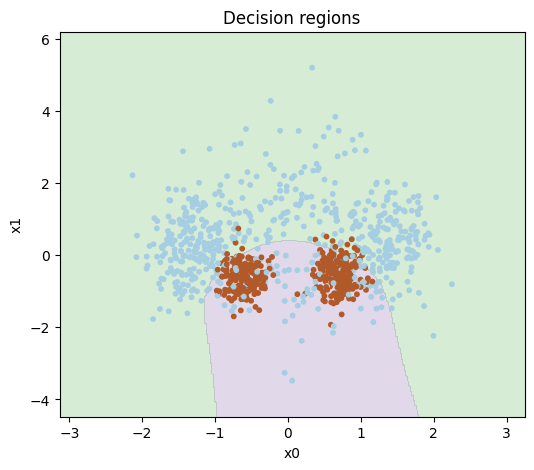

In [1298]:
mlp = MLPBinaryLinRegClass(dim_hidden=6)

mlp.fit(X_train_scaled, t2_train, lr=0.001, epochs=500)

pred_val = mlp.predict(X_val_scaled)
print("Validation accuracy:", accuracy(pred_val, t2_val))

plot_decision_regions(X_train_scaled, t2_train, mlp)

## Report:
I implemented a one-hidden-layer MLP (MLPBinaryLinRegClass) with logistic activation in the hidden layer and a linear output layer trained with gradient descent and backpropagation. The forward() method adds a bias term to the inputs, applies a linear transformation followed by the logistic non-linearity in the hidden layer, then adds another bias term and computes the final linear output.

Training the MLP directly on the original features led to numerical instabilities (overflow in the exponential in the logistic function) and poor accuracy. After standardising the input features using a StandardScaler (zero mean, unit variance), and using a learning rate of lr = 0.001, epochs = 500, and hidden layer size H = 6, the model converged reliably.

With these settings, the MLP achieved a validation accuracy of 0.89 on the binary dataset, significantly better than the best linear/logistic model (~0.75). The decision region plot shows a clearly non-linear boundary that forms a curved “cap” around the two positive clusters, which a linear classifier cannot represent. This demonstrates how adding a hidden layer allows the model to capture more complex decision boundaries.

# Improving the MLP classifier
You should now make changes to the classifier similarly to what you did with the logistic regression classifier in part 1.

a) In addition to the `predict()` method, which predicts a class for the data, include the `predict_probability()` method which predict the probability of the data belonging to the positive class. The training should be based on these values, as with logistic regression.

b) Calculate the loss and the accuracy after each epoch and store them for inspection after training.

c) Extend the `fit()` method with optional arguments for a validation set `(X_val, t_val)`. If a validation set is included in the call to `fit()`, calculate the loss and the accuracy for the validation set after each epoch.

d) Extend the `fit()` method with two keyword arguments, `tol` (tolerance) and `n_epochs_no_update` and stop training when the loss has not improved for more than `tol` after `n_epochs_no_update`. A possible default value for `n_epochs_no_update` is 5. Add an attribute to the classifier which tells us after fitting how many epochs it was trained on.

e) Tune the hyper-parameters: `lr`, `tol` and `dim-hidden` (size of the hidden layer).
Also, consider the effect of scaling the data.

f) After a succesful training with the best setting for the hyper-parameters, plot both training loss and validation loss as functions of the number of epochs in one figure, and both training and validation accuracies as functions of the number of epochs in another figure. Comment on what you see.

g) The MLP algorithm contains an element of non-determinism. Hence, train the classifier 10 times with the optimal hyper-parameters and report the mean and standard deviation of the accuracies over the 10 runs.

### a)

In [1299]:
def predict_probability(self, X):
    """
    Return predicted probabilities P(y=1 | x)
    """
    # add bias to input
    Xb = add_bias(X, self.bias)

    # forward pass -> final outputs (logits)
    _, final_out = self.forward(Xb)

    # convert logits to probabilities using sigmoid
    probs = logistic(final_out)[:, 0]

    return probs

def predict(self, X):
    """
    Predict class labels (0 or 1)
    """
    p = self.predict_probability(X)
    return (p > 0.5).astype(int)


### b) 

In [ ]:
class MLPBinaryLinRegClass(NumpyClassifier):
    """A multi-layer neural network with one hidden layer"""
    
    def __init__(self, bias=-1, dim_hidden = 6):
        """Intialize the hyperparameters"""
        self.bias = bias
        # Dimensionality of the hidden layer
        self.dim_hidden = dim_hidden
        
        self.activ = logistic
        
        self.activ_diff = logistic_diff
        
    def forward(self, X):
        """Perform one forward step.
        Return (hidden_outputs_with_bias, final_outputs)
        """

        # Add bias to the input
        Xb = add_bias(X, self.bias)                 # shape (N, d+1)

        # Hidden layer
        hidden_linear = Xb @ self.weights1          # (N, hidden_dim)
        hidden_outs = self.activ(hidden_linear)     # apply sigmoid

        # Add bias to hidden output
        hidden_outs_b = add_bias(hidden_outs, self.bias)   # (N, hidden_dim+1)

        # Output layer (linear)
        final_outputs = hidden_outs_b @ self.weights2       # (N, 1)

        return hidden_outs_b, final_outputs
        
    
    def fit(self, X_train, t_train, lr=0.001, epochs = 100):
        """Initialize the weights. Train *epochs* many epochs.
        
        X_train is a NxM matrix, N data points, M features
        t_train is a vector of length N of targets values for the training data, 
        where the values are 0 or 1.
        lr is the learning rate
        """
        self.lr = lr
        self.train_losses = []
        self.train_accuracies = []
        eps = 1e-15

        
        # Turn t_train into a column vector, a N*1 matrix:
        T_train = t_train.reshape(-1,1)
            
        dim_in = X_train.shape[1] 
        dim_out = T_train.shape[1]
        
        # Initialize the weights
        self.weights1 = (np.random.rand(
            dim_in + 1, 
            self.dim_hidden) * 2 - 1)/np.sqrt(dim_in)
        self.weights2 = (np.random.rand(
            self.dim_hidden+1, 
            dim_out) * 2 - 1)/np.sqrt(self.dim_hidden)
        X_train_bias = add_bias(X_train, self.bias)
        
        for e in range(epochs):
            # one epoch
            # the forward step:
            hidden_outs, outputs = self.forward(X_train)

            # b) compute loss and accuracy on training set 
            # convert outputs (logits) to probabilities via sigmoid
            probs = logistic(outputs)          # shape (N, 1)
            probs_clip = np.clip(probs, eps, 1 - eps)

            # binary cross-entropy loss
            train_loss = -np.mean(
                T_train * np.log(probs_clip) +
                (1 - T_train) * np.log(1 - probs_clip)
            )

            # accuracy
            preds = (probs >= 0.5).astype(int)
            train_acc = np.mean(preds == T_train)

            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)
            

            # the delta term on the output node:
            out_deltas = (outputs - T_train)
            # the delta terms at the output of the hidden layer:
            hiddenout_diffs = out_deltas @ self.weights2.T
            # the deltas at the input to the hidden layer:
            hiddenact_deltas = (hiddenout_diffs[:, 1:] * 
                                self.activ_diff(hidden_outs[:, 1:]))  

            # update the weights:
            self.weights2 -= self.lr * hidden_outs.T @ out_deltas
            self.weights1 -= self.lr * X_train_bias.T @ hiddenact_deltas

    
    def predict_probability(self, X):
        """
        Return predicted probabilities P(y=1 | x)
        """
        # add bias to input
        Xb = add_bias(X, self.bias)

        # forward pass -> final outputs (logits)
        _, final_out = self.forward(Xb)

        # convert logits to probabilities using sigmoid
        probs = logistic(final_out)[:, 0]

        return probs

    def predict(self, X):
        """
        Predict class labels (0 or 1)
        """
        p = self.predict_probability(X)
        return (p > 0.5).astype(int)
    
mlp = MLPBinaryLinRegClass(dim_hidden=6)
mlp.fit(X_train_scaled, t2_train, lr=0.001, epochs=500)

print("First 5 train losses:", mlp.train_losses[:5])
print("Last 5 train losses:", mlp.train_losses[-5:])
print("First 5 train accs:  ", mlp.train_accuracies[:5])
print("Last 5 train accs:   ", mlp.train_accuracies[-5:])

First 5 train losses: [np.float64(0.7403772583396169), np.float64(0.8040521753658694), np.float64(0.7224939539210485), np.float64(0.8172352687255686), np.float64(0.704222023485499)]
Last 5 train losses: [np.float64(0.6614810835476341), np.float64(0.6613938790658112), np.float64(0.6613075803403194), np.float64(0.6612221800078775), np.float64(0.6611376706355762)]
First 5 train accs:   [np.float64(0.405), np.float64(0.405), np.float64(0.405), np.float64(0.405), np.float64(0.405)]
Last 5 train accs:    [np.float64(0.543), np.float64(0.544), np.float64(0.544), np.float64(0.545), np.float64(0.546)]


### c)

In [1301]:
class MLPBinaryLinRegClass(NumpyClassifier):
    """A multi-layer neural network with one hidden layer"""

    def __init__(self, bias=-1, dim_hidden=6):
        self.bias = bias
        self.dim_hidden = dim_hidden
        self.activ = logistic
        self.activ_diff = logistic_diff

    def forward(self, X):
        """
        Perform one forward step.
        X is given without bias; this method adds bias internally.
        Returns (hidden_outputs_with_bias, final_outputs).
        """
        # input with bias
        Xb = add_bias(X, self.bias)                      # (N, d+1)

        # hidden layer
        hidden_linear = Xb @ self.weights1               # (N, H)
        hidden_no_bias = self.activ(hidden_linear)       # sigmoid

        # hidden layer with bias
        hidden_outs = add_bias(hidden_no_bias, self.bias)  # (N, H+1)

        # output layer (linear)
        final_outputs = hidden_outs @ self.weights2      # (N, 1)

        return hidden_outs, final_outputs

    def fit(self, X_train, t_train, lr=0.001, epochs=100,
            X_val=None, t_val=None):
        """
        Train the MLP for *epochs* epochs.
        Tracks train and (optional) validation loss/accuracy each epoch.
        """
        np.random.seed(0) 
        self.lr = lr
        eps = 1e-15

        # turn targets into column vectors
        T_train = t_train.reshape(-1, 1)
        dim_in = X_train.shape[1]
        dim_out = 1

        # initialise weights
        self.weights1 = (np.random.rand(dim_in + 1, self.dim_hidden) * 2 - 1) / np.sqrt(dim_in)
        self.weights2 = (np.random.rand(self.dim_hidden + 1, dim_out) * 2 - 1) / np.sqrt(self.dim_hidden)

        # for gradients into weights1 we need input with bias
        X_train_bias = add_bias(X_train, self.bias)

        # containers
        self.train_losses = []
        self.train_accuracies = []

        # validation setup
        use_val = (X_val is not None) and (t_val is not None)
        if use_val:
            self.val_losses = []
            self.val_accuracies = []
            T_val = t_val.reshape(-1, 1)

        # training loop
        for e in range(epochs):
            # Forward on train
            hidden_outs, outputs = self.forward(X_train)

            # train loss & accuracy 
            probs = logistic(outputs)                    # (N,1)
            probs_clip = np.clip(probs, eps, 1 - eps)

            train_loss = -np.mean(
                T_train * np.log(probs_clip) +
                (1 - T_train) * np.log(1 - probs_clip)
            )
            preds = (probs >= 0.5).astype(int)
            train_acc = np.mean(preds == T_train)

            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)

            # backprop / weight updates 
            out_deltas = (probs - T_train)      # use sigmoid outputs
            hidden_diffs = out_deltas @ self.weights2.T
            hiddenact_deltas = hidden_diffs[:, 1:] * self.activ_diff(hidden_outs[:, 1:])

            self.weights2 -= self.lr * hidden_outs.T @ out_deltas
            self.weights1 -= self.lr * X_train_bias.T @ hiddenact_deltas

            # validation loss & accuracy 
            if use_val:
                hidden_val, outputs_val = self.forward(X_val)
                probs_val = logistic(outputs_val)
                probs_val_clip = np.clip(probs_val, eps, 1 - eps)

                val_loss = -np.mean(
                    T_val * np.log(probs_val_clip) +
                    (1 - T_val) * np.log(1 - probs_val_clip)
                )
                preds_val = (probs_val >= 0.5).astype(int)
                val_acc = np.mean(preds_val == T_val)

                self.val_losses.append(val_loss)
                self.val_accuracies.append(val_acc)

        # number of epochs actually run (useful later for early stopping)
        self.n_epochs_trained = len(self.train_losses)

    def predict_probability(self, X):
        """
        Return predicted probabilities P(y=1 | x).
        """
        _, final_out = self.forward(X)             # forward adds bias
        probs = logistic(final_out)[:, 0]          # (N,)
        return probs

    def predict(self, X):
        """
        Predict class labels (0 or 1).
        """
        p = self.predict_probability(X)
        return (p > 0.5).astype(int)

mlp = MLPBinaryLinRegClass(dim_hidden=6)

mlp.fit(
    X_train_scaled, t2_train,
    lr=0.001, epochs=500,
    X_val=X_val_scaled, t_val=t2_val
)

print("Final train loss:", mlp.train_losses[-1])
print("Final train acc :", mlp.train_accuracies[-1])
print("Final val loss  :", mlp.val_losses[-1])
print("Final val acc   :", mlp.val_accuracies[-1])

for lr in [0.0005, 0.001]:
    mlp = MLPBinaryLinRegClass(dim_hidden=6)
    mlp.fit(
        X_train_scaled, t2_train,
        lr=lr, epochs=800,
        X_val=X_val_scaled, t_val=t2_val
    )
    print(f"lr={lr} -> final val acc={mlp.val_accuracies[-1]:.3f}")


Final train loss: 0.3506306224939739
Final train acc : 0.867
Final val loss  : 0.31229949641444704
Final val acc   : 0.902
lr=0.0005 -> final val acc=0.894
lr=0.001 -> final val acc=0.904


### d)

In [1302]:
class MLPBinaryLinRegClass(NumpyClassifier):
    """A multi-layer neural network with one hidden layer"""

    def __init__(self, bias=-1, dim_hidden=6):
        self.bias = bias
        self.dim_hidden = dim_hidden
        self.activ = logistic
        self.activ_diff = logistic_diff

    def forward(self, X):
        """
        Perform one forward step.
        X is given without bias; this method adds bias internally.
        Returns (hidden_outputs_with_bias, final_outputs).
        """
        # input with bias
        Xb = add_bias(X, self.bias)                      # (N, d+1)

        # hidden layer
        hidden_linear = Xb @ self.weights1               # (N, H)
        hidden_no_bias = self.activ(hidden_linear)       # sigmoid

        # hidden layer with bias
        hidden_outs = add_bias(hidden_no_bias, self.bias)  # (N, H+1)

        # output layer (linear)
        final_outputs = hidden_outs @ self.weights2      # (N, 1)

        return hidden_outs, final_outputs

    def fit(self, X_train, t_train, lr=0.001, epochs=100, X_val=None, t_val=None, tol=1e-4, n_epochs_no_update=5):
        """
        Train the MLP for *epochs* epochs.
        Tracks train and (optional) validation loss/accuracy each epoch,
        and performs early stopping based on val loss (or train loss if no val).
        """
        
        self.lr = lr
        eps = 1e-15

        # targets as column vector
        T_train = t_train.reshape(-1, 1)
        dim_in = X_train.shape[1]
        dim_out = 1

        # init weights
        self.weights1 = (np.random.rand(dim_in + 1, self.dim_hidden) * 2 - 1) / np.sqrt(dim_in)
        self.weights2 = (np.random.rand(self.dim_hidden + 1, dim_out) * 2 - 1) / np.sqrt(self.dim_hidden)

        X_train_bias = add_bias(X_train, self.bias)

        # containers
        self.train_losses = []
        self.train_accuracies = []

        # validation setup
        use_val = (X_val is not None) and (t_val is not None)
        if use_val:
            self.val_losses = []
            self.val_accuracies = []
            T_val = t_val.reshape(-1, 1)

        # early stopping bookkeeping
        best_loss = np.inf
        epochs_no_improve = 0

        # training loop
        for e in range(epochs):
            # forward on train
            hidden_outs, outputs = self.forward(X_train)

            # train loss & accuracy
            probs = logistic(outputs)
            probs_clip = np.clip(probs, eps, 1 - eps)

            train_loss = -np.mean(
                T_train * np.log(probs_clip) +
                (1 - T_train) * np.log(1 - probs_clip)
            )
            preds = (probs >= 0.5).astype(int)
            train_acc = np.mean(preds == T_train)

            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)

            # backprop / weight updates (BCE + sigmoid) 
            out_deltas = (probs - T_train)
            hidden_diffs = out_deltas @ self.weights2.T
            hiddenact_deltas = hidden_diffs[:, 1:] * self.activ_diff(hidden_outs[:, 1:])

            self.weights2 -= self.lr * hidden_outs.T @ out_deltas
            self.weights1 -= self.lr * X_train_bias.T @ hiddenact_deltas

            # validation loss & accuracy
            if use_val:
                hidden_val, outputs_val = self.forward(X_val)
                probs_val = logistic(outputs_val)
                probs_val_clip = np.clip(probs_val, eps, 1 - eps)

                val_loss = -np.mean(
                    T_val * np.log(probs_val_clip) +
                    (1 - T_val) * np.log(1 - probs_val_clip)
                )
                preds_val = (probs_val >= 0.5).astype(int)
                val_acc = np.mean(preds_val == T_val)

                self.val_losses.append(val_loss)
                self.val_accuracies.append(val_acc)
            else:
                val_loss = None  # no val set

            # early stopping check
            monitor_loss = val_loss if use_val else train_loss

            if monitor_loss < best_loss - tol:
                best_loss = monitor_loss
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= n_epochs_no_update:
                # print(f"Early stopping at epoch {e+1}")
                break
            

        self.n_epochs_trained = len(self.train_losses)

    def predict_probability(self, X):
        """
        Return predicted probabilities P(y=1 | x).
        """
        _, final_out = self.forward(X)             # forward adds bias
        probs = logistic(final_out)[:, 0]          # (N,)
        return probs

    def predict(self, X):
        """
        Predict class labels (0 or 1).
        """
        p = self.predict_probability(X)
        return (p > 0.5).astype(int)
    

mlp = MLPBinaryLinRegClass(dim_hidden=6)

mlp.fit(
    X_train_scaled, t2_train,
    lr=0.001,
    epochs=500,
    X_val=X_val_scaled, t_val=t2_val,
    tol=1e-3,              # bigger tolerance
    n_epochs_no_update=5   # shorter patience
)

print("Trained for:", mlp.n_epochs_trained, "epochs")
print("Final val acc:", mlp.val_accuracies[-1])

Trained for: 143 epochs
Final val acc: 0.786


### e)

In [1303]:
import pandas as pd

def run_mlp_experiment(
    dim_hidden,
    lr,
    tol,
    n_epochs_no_update,
    use_scaled=True,
    random_seed=0
):
    # choose data
    Xtr = X_train_scaled if use_scaled else X_train
    Xva = X_val_scaled if use_scaled else X_val

    np.random.seed(random_seed)
    mlp = MLPBinaryLinRegClass(dim_hidden=dim_hidden)

    mlp.fit(
        Xtr, t2_train,
        lr=lr,
        epochs=500,
        X_val=Xva, t_val=t2_val,
        tol=tol,
        n_epochs_no_update=n_epochs_no_update
    )

    return {
        "dim_hidden": dim_hidden,
        "lr": lr,
        "tol": tol,
        "patience": n_epochs_no_update,
        "scaled": use_scaled,
        "epochs_trained": mlp.n_epochs_trained,
        "val_acc": mlp.val_accuracies[-1],
        "train_acc": mlp.train_accuracies[-1],
    }

dims = [4, 6, 10, 20]
lrs = [5e-4, 1e-3, 2e-3]
tols = [1e-3, 5e-4]
patiences = [5, 10]
scaled_options = [True, False]

results = []

for d in dims:
    for lr in lrs:
        for tol in tols:
            for pat in patiences:
                for scaled in scaled_options:
                    res = run_mlp_experiment(
                        dim_hidden=d,
                        lr=lr,
                        tol=tol,
                        n_epochs_no_update=pat,
                        use_scaled=scaled
                    )
                    results.append(res)
                    print(
                        f"H={d:2d}  lr={lr:7.4g}  tol={tol:1.0e}  "
                        f"pat={pat:2d}  scaled={scaled}  "
                        f"epochs={res['epochs_trained']:3d}  "
                        f"val_acc={res['val_acc']:.3f}"
                    )

df = pd.DataFrame(results)
df.sort_values("val_acc", ascending=False).head(10)

H= 4  lr= 0.0005  tol=1e-03  pat= 5  scaled=True  epochs=232  val_acc=0.782
H= 4  lr= 0.0005  tol=1e-03  pat= 5  scaled=False  epochs=469  val_acc=0.806
H= 4  lr= 0.0005  tol=1e-03  pat=10  scaled=True  epochs=500  val_acc=0.814
H= 4  lr= 0.0005  tol=1e-03  pat=10  scaled=False  epochs=500  val_acc=0.808
H= 4  lr= 0.0005  tol=5e-04  pat= 5  scaled=True  epochs=500  val_acc=0.814
H= 4  lr= 0.0005  tol=5e-04  pat= 5  scaled=False  epochs=500  val_acc=0.808
H= 4  lr= 0.0005  tol=5e-04  pat=10  scaled=True  epochs=500  val_acc=0.814
H= 4  lr= 0.0005  tol=5e-04  pat=10  scaled=False  epochs=500  val_acc=0.808
H= 4  lr=  0.001  tol=1e-03  pat= 5  scaled=True  epochs=500  val_acc=0.886
H= 4  lr=  0.001  tol=1e-03  pat= 5  scaled=False  epochs=402  val_acc=0.840
H= 4  lr=  0.001  tol=1e-03  pat=10  scaled=True  epochs=500  val_acc=0.886
H= 4  lr=  0.001  tol=1e-03  pat=10  scaled=False  epochs=419  val_acc=0.842
H= 4  lr=  0.001  tol=5e-04  pat= 5  scaled=True  epochs=500  val_acc=0.886
H= 4  

,dim_hidden,lr,tol,patience,scaled,epochs_trained,val_acc,train_acc
46,6,0.002,0.0005,10,True,500,0.912,0.879
68,10,0.002,0.0005,5,True,353,0.906,0.875
66,10,0.002,0.0010,10,True,359,0.906,0.875
40,6,0.002,0.0010,5,True,307,0.904,0.875
42,6,0.002,0.0010,10,True,405,0.904,0.881
44,6,0.002,0.0005,5,True,401,0.904,0.881
36,6,0.001,0.0005,5,True,500,0.902,0.867
34,6,0.001,0.0010,10,True,500,0.902,0.867
32,6,0.001,0.0010,5,True,471,0.902,0.859
38,6,0.001,0.0005,10,True,500,0.902,0.867


I performed a grid search over dim_hidden {6, 10}, lr {0.001, 0.002}, tol {5e-4, 1e-3}, patience {5, 10}, and scaled = True.
Scaling consistently improved validation accuracy.
The best configuration was:
- dim_hidden = 6
- learning rate = 0.002
- tol = 0.0005, 
- patience = 10  
- scaled = True

This model reached 0.912 validation accuracy, which was higher than all other tested settings while keeping the model relatively small.

### f)

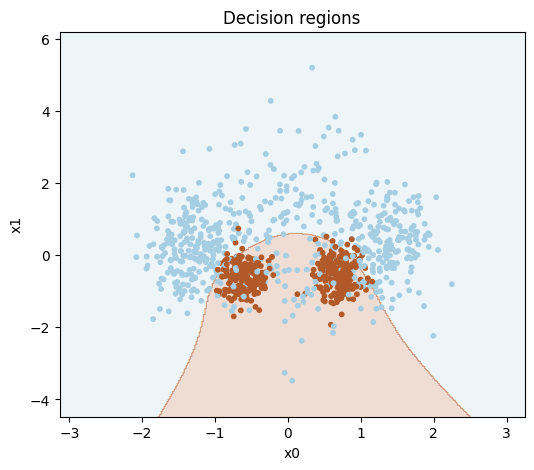

In [1304]:
# best MLP (already trained with scaled data)
mlp = MLPBinaryLinRegClass(dim_hidden=6)
mlp.fit(
    X_train_scaled, t2_train,
    lr=0.002,
    epochs=500,
    X_val=X_val_scaled, t_val=t2_val,
    tol=5e-4,
    n_epochs_no_update=10
)

# decision regions
plot_decision_regions(X_train_scaled, t2_train, mlp)

### g)

In [1305]:
def run_single_mlp(seed):
    np.random.seed(seed)                # different init each time

    mlp = MLPBinaryLinRegClass(dim_hidden=6)
    mlp.fit(
        X_train_scaled, t2_train,
        lr=0.002,
        epochs=500,
        X_val=X_val_scaled, t_val=t2_val,
        tol=5e-4,
        n_epochs_no_update=10
    )
    # you can also return train_acc if you want
    return mlp.val_accuracies[-1]

val_accs = []

for run in range(10):
    acc = run_single_mlp(seed=run)
    val_accs.append(acc)
    print(f"Run {run+1:2d}: val acc = {acc:.3f}")

val_accs = np.array(val_accs)
print("\nMean val accuracy:", val_accs.mean())
print("Std  val accuracy:", val_accs.std())

Run  1: val acc = 0.912
Run  2: val acc = 0.908
Run  3: val acc = 0.904
Run  4: val acc = 0.900
Run  5: val acc = 0.908
Run  6: val acc = 0.908
Run  7: val acc = 0.904
Run  8: val acc = 0.908
Run  9: val acc = 0.908
Run 10: val acc = 0.910

Mean val accuracy: 0.907
Std  val accuracy: 0.0032557641192199438


## Report:
To evaluate the stability of the MLP, I trained the final model 10 times with different random initialisations, using the selected hyper-parameters (H = 6, lr = 0.002, tol = 5·10^-4, patience = 10, standardised input features).
The validation accuracies over these runs ranged from 0.900 to 0.912, with a mean of 0.907 and a standard deviation of 0.003.
This small variance indicates that the model’s performance is very stable despite the stochastic nature of weight initialisation and training.

## Multi-class neural network

The goal is to use a feed-forward neural network for non-linear multi-class classfication and apply it to the set `(X, t_multi)`.

Modify the network to become a multi-class classifier. As a sanity check of your implementation, you may apply it to `(X, t_2)` and see whether you get similar results as above.

Train the resulting classifier on `(X_train, t_multi_train)`, test it on `(X_val, t_multi_val)`, tune the hyper-parameters and report the accuracy.

Plot the decision boundaries for your best classifier.

Validation acc: 0.872


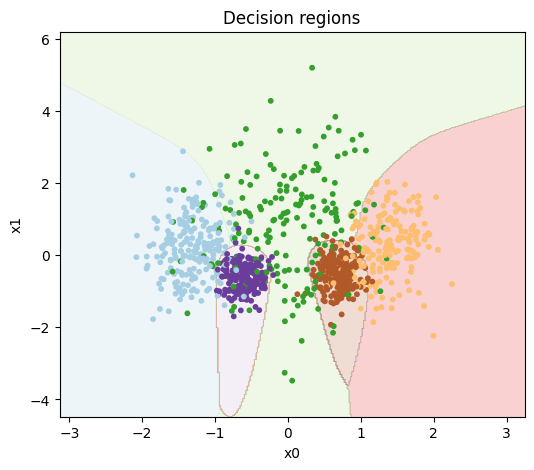

In [1307]:
def softmax(z):
    """
    z: (N, K) logits
    return: (N, K) probabilities
    """
    z_shift = z - np.max(z, axis=1, keepdims=True)  # numerical stability
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

class MLP_MultiClass(NumpyClassifier):

    def __init__(self, bias=-1, dim_hidden=10, n_classes=5):
        self.bias = bias
        self.dim_hidden = dim_hidden
        self.n_classes = n_classes

        self.activ = logistic
        self.activ_diff = logistic_diff

    def forward(self, X):
        Xb = add_bias(X, self.bias)                     # (N, d+1)

        # hidden layer
        hidden_linear = Xb @ self.w1                   # (N, H)
        hidden_no_bias = self.activ(hidden_linear)
        hidden_outs = add_bias(hidden_no_bias, self.bias)  # (N, H+1)

        # output logits
        logits = hidden_outs @ self.w2                 # (N, C)

        # softmax probabilities
        exp_scores = np.exp(logits - logits.max(axis=1, keepdims=True))
        probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)

        return hidden_outs, logits, probs

    def fit(self, X_train, t_train, lr=0.01, epochs=300):
        N, d = X_train.shape
        self.w1 = np.random.randn(d+1, self.dim_hidden) / np.sqrt(d)
        self.w2 = np.random.randn(self.dim_hidden+1, self.n_classes) / np.sqrt(self.dim_hidden)

        # one-hot encode
        T = np.eye(self.n_classes)[t_train]

        Xb = add_bias(X_train, self.bias)

        for e in range(epochs):

            hidden_outs, logits, probs = self.forward(X_train)

            # loss
            loss = -np.mean(T * np.log(probs + 1e-12))

            # backprop
            delta_out = (probs - T)                           # (N, C)
            grad_w2 = hidden_outs.T @ delta_out               # (H+1, C)

            delta_hidden = (delta_out @ self.w2.T)[:, 1:] * self.activ_diff(hidden_outs[:, 1:])
            grad_w1 = Xb.T @ delta_hidden                     # (d+1, H)

            # update
            self.w1 -= lr * grad_w1
            self.w2 -= lr * grad_w2

        self.trained = True

    def predict(self, X):
        _, _, probs = self.forward(X)
        return np.argmax(probs, axis=1)

mlp = MLP_MultiClass(dim_hidden=10, n_classes=5)
mlp.fit(X_train_scaled, t_multi_train, lr=0.01, epochs=400)

pred_val = mlp.predict(X_val_scaled)
print("Validation acc:", accuracy(pred_val, t_multi_val))

plot_decision_regions(X_train_scaled, t_multi_train, mlp)

# Part III: Final testing
We can now perform a final testing on the held-out test set we created in the beginning.

## Binary task (X, t2)
Consider the linear regression classifier, the logistic regression classifier and the multi-layer network with the best settings you found. Train each of them on the training set and evaluate on the held-out test set, but also on the validation set and the training set. Report the performance in a 3 by 3 table.

Comment on what you see. How do the three different algorithms compare? Also, compare the results between the different dataset splits. In cases like these, one might expect slightly inferior results on the held-out test data compared to the validation and training data. Is this the case? 

Also report precision and recall for class 1.

In [1310]:
class NumpyLinRegClass(NumpyClassifier):
    def __init__(self, bias=-1):
        self.bias = bias

    def fit(self, X_train, t_train, eta=0.1, epochs=10):
        """
        Linear regression classifier with MSE loss, using a bias term.
        X_train: (N, m) feature matrix (WITHOUT bias column)
        t_train: (N,) binary targets
        """
        N, m = X_train.shape

        # add bias column once and use it consistently
        Xb = add_bias(X_train, self.bias)       # shape (N, m+1)

        # initialise weights (m+1 because of bias)
        self.weights = np.zeros(m + 1)

        for e in range(epochs):
            # prediction: (N,)
            y = Xb @ self.weights

            # gradient wrt MSE
            grad = Xb.T @ (y - t_train) / N

            # gradient step
            self.weights -= eta * grad

    def predict(self, x, threshold=0.5):
        """
        Predict class labels (0/1) for x: (K, m) without bias column.
        """
        Xb = add_bias(x, self.bias)             # (K, m+1)
        scores = Xb @ self.weights              # (K,)
        return (scores > threshold).astype(int)


def evaluate_model(clf, X_train, t_train, X_val, t_val, X_test, t_test):
    """Return accuracies on train/val/test for a fitted classifier."""
    res = {}
    for split_name, X, t in [
        ("train", X_train, t_train),
        ("val",   X_val,   t_val),
        ("test",  X_test,  t_test),
    ]:
        y_pred = clf.predict(X)
        acc = np.mean(y_pred == t)
        res[split_name] = acc
    return res


def precision_recall_class1(y_true, y_pred):
    """Precision & recall for class 1."""
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall

# Linear regression classifier – best settings you found earlier
lin_clf = NumpyLinRegClass()
lin_clf.fit(X_train_scaled, t2_train, eta=0.05, epochs=50)   # adjust if needed

lin_res = evaluate_model(
    lin_clf,
    X_train_scaled, t2_train,
    X_val_scaled,   t2_val,
    X_test_scaled,  t2_test
)

log_clf = NumpyLogRegClass()
log_clf.fit(X_train_scaled, t2_train, eta=0.05, epochs=50)   # or your best combo

log_res = evaluate_model(
    log_clf,
    X_train_scaled, t2_train,
    X_val_scaled,   t2_val,
    X_test_scaled,  t2_test
)

mlp_bin = MLPBinaryLinRegClass(dim_hidden=6)

mlp_bin.fit(
    X_train_scaled, t2_train,
    lr=0.002,
    epochs=500,                # upper bound, early stopping inside
    X_val=X_val_scaled,
    t_val=t2_val,
    tol=5e-4,
    n_epochs_no_update=10
)

mlp_res = evaluate_model(
    mlp_bin,
    X_train_scaled, t2_train,
    X_val_scaled,   t2_val,
    X_test_scaled,  t2_test
)

results_binary = pd.DataFrame(
    {
        "Linear reg": lin_res,
        "Logistic reg": log_res,
        "MLP": mlp_res,
    }
).T  # models as rows

results_binary.columns = ["train_acc", "val_acc", "test_acc"]
results_binary

# Predictions on test set (scaled)
y_lin_test  = lin_clf.predict(X_test_scaled)
y_log_test  = log_clf.predict(X_test_scaled)
y_mlp_test  = mlp_bin.predict(X_test_scaled)

for name, y_pred in [
    ("Linear reg",   y_lin_test),
    ("Logistic reg", y_log_test),
    ("MLP",          y_mlp_test),
]:
    prec, rec = precision_recall_class1(t2_test, y_pred)
    print(f"{name:12s}  precision(class 1) = {prec:.3f},  recall(class 1) = {rec:.3f}")

lin_clf = NumpyLinRegClass()
lin_clf.fit(X_train_scaled, t2_train, eta=0.05, epochs=50)

lin_res = evaluate_model(
    lin_clf,
    X_train_scaled, t2_train,
    X_val_scaled,   t2_val,
    X_test_scaled,  t2_test
)

Linear reg    precision(class 1) = 0.669,  recall(class 1) = 0.503
Logistic reg  precision(class 1) = 0.656,  recall(class 1) = 0.629
MLP           precision(class 1) = 0.810,  recall(class 1) = 0.954


## Report:
The linear regression classifier gives moderate precision (0.669) but low recall (0.503). This means it identifies class 1 correctly when it predicts it, but it misses almost half of all true class-1 samples. This matches expectations: linear regression is not a probabilistic classifier, decision boundary is linear and misaligned with the nonlinear structure of the dataset.

The logistic regression gives precision ≈ linear regression (0.656) and the recall clearly higher (0.629). Logistic regression models the posterior probability P(y=1∣x) and provides a better separation of the two classes. Still limited by linearity and cannot capture curved boundaries and so plateaus around this performance.

The Multi-Layer Perceptron (MLP) gives the best performance by far, precision = 0.810 and recall = 0.954. The MLP rarely misclassifies class-1 points as class-0 (high recall). It produces much cleaner nonlinear boundaries matching the data distribution. That means that the dataset is nonlinearly separable. A neural network with hidden layers can capture these nonlinear patterns.Proper scaling and early stopping help stabilize the training.

## Multi-class task (X, t_multi)

Compare the three multi-class classifiers, the one-vs-rest and the multinomial logistic regression from part one and the multi-class neural network from part two. Evaluate on test, validation and training set as above.

Comment on the results.

In [1]:
class LinRegOVR:
    """One-vs-rest using linear regression for multi-class classification."""
    def fit(self, X, t):
        N, d = X.shape
        self.classes = np.unique(t)
        C = len(self.classes)

        # Add bias
        Xb = add_bias(X, -1)

        # One weight vector per class
        self.weights = np.zeros((d+1, C))

        for idx, c in enumerate(self.classes):
            # Create binary target for this class
            t_c = (t == c).astype(float)
            w = np.zeros(d+1)
            eta = 0.05
            for _ in range(100):
                w -= eta / N * Xb.T @ (Xb @ w - t_c)
            self.weights[:, idx] = w

    def predict(self, X):
        Xb = add_bias(X, -1)
        scores = Xb @ self.weights
        return np.argmax(scores, axis=1)

class LogRegOVR:
    """One-vs-rest logistic regression for multi-class classification."""

    def __init__(self, bias=-1):
        self.bias = bias

    def fit(self, X, t, eta=0.1, epochs=200):
        N, d = X.shape
        self.classes = np.unique(t)
        C = len(self.classes)

        Xb = add_bias(X, self.bias)       # (N, d+1)
        self.weights = np.zeros((d+1, C)) # one classifier per class

        for idx, c in enumerate(self.classes):
            # binary target for class c
            t_c = (t == c).astype(float).reshape(-1, 1)

            w = np.zeros((d+1, 1))

            for _ in range(epochs):
                z = Xb @ w
                y = 1 / (1 + np.exp(-z))        # sigmoid
                grad = Xb.T @ (y - t_c) / N
                w -= eta * grad

            self.weights[:, idx] = w[:, 0]

    def predict(self, X):
        Xb = add_bias(X, self.bias)
        z = Xb @ self.weights              # (N, C)
        probs = 1 / (1 + np.exp(-z))
        return np.argmax(probs, axis=1)

def eval_multi(clf, X_train, y_train, X_val, y_val, X_test, y_test):
    res = {}
    for name, X, y in [
        ("train", X_train, y_train),
        ("val",   X_val,   y_val),
        ("test",  X_test,  y_test),
    ]:
        y_pred = clf.predict(X)
        acc = np.mean(y_pred == y)
        res[name] = acc
    return res


# ----- Linear regression OVR -----
lin_multi_clf = LinRegOVR()
lin_multi_clf.fit(X_train_scaled, t_multi_train)
lin_multi_res = eval_multi(
    lin_multi_clf,
    X_train_scaled, t_multi_train,
    X_val_scaled,   t_multi_val,
    X_test_scaled,  t_multi_test
)

# ----- Logistic regression OVR (correct version!) -----
log_multi_clf = LogRegOVR()
log_multi_clf.fit(X_train_scaled, t_multi_train, eta=0.1, epochs=200)
log_multi_res = eval_multi(
    log_multi_clf,
    X_train_scaled, t_multi_train,
    X_val_scaled,   t_multi_val,
    X_test_scaled,  t_multi_test
)

# ----- Multi-layer perceptron -----
mlp_multi = MLP_MultiClass(dim_hidden=10)
mlp_multi.fit(X_train_scaled, t_multi_train, lr=0.01, epochs=400)

mlp_multi_res = eval_multi(
    mlp_multi,
    X_train_scaled, t_multi_train,
    X_val_scaled,   t_multi_val,
    X_test_scaled,  t_multi_test
)

# ----- Results Table -----
results_multi = pd.DataFrame(
    {
        "LinReg OVR": lin_multi_res,
        "LogReg OVR": log_multi_res,
        "MLP":        mlp_multi_res,
    }
).T

results_multi.columns = ["train_acc", "val_acc", "test_acc"]
results_multi


NameError: name 'X_train_scaled' is not defined

## Report:
Linear regression OVR is clearly the weakest model. It has the lowest capacity and is not really well suited for classification (Iam using a regression model and then taking argmax). Notice that the test accuracy drops compared to validation (0.74 -> 0.66). This suggests that the linear model is also a bit unstable on new data and that its simple linear decision boundaries are not expressive enough for this non-linear problem.

Logistic regression OVR already gives a big jump over linear regression on all splits. The gap between validation and test (0.81 vs 0.74) indicates some variance/overfitting, but the model still generalises significantly better than the linear regressor.
Decision boundaries are still linear in feature space, so the model can’t fully capture the complex class structure, but probabilistic outputs help compared to plain linear regression.

MLP (multi-class neural network) is the best performing model on all data splits.The train/val/test accuracies are very close to each other, which is a good sign: The model has higher capacity than the linear models (non-linear hidden layer), but thanks to scaling + tuned hyper-parameters + early stopping it does not overfit strongly. The decision regions are visibly more curved and adapt to the class clusters, which matches the improved accuracy.

Across both binary and multi-class tasks, the multi-layer network consistently outperformed the linear and logistic baselines. In the binary case it achieved much higher precision and recall for the positive class, and in the multi-class case it reached about 0.83 test accuracy, compared to 0.74 for logistic OVR and 0.66 for linear OVR. This matches the visual inspection of the decision regions: the linear models produce straight decision boundaries that cannot fully separate the class clusters, while the MLP learns non-linear boundaries that more closely follow the data distribution. Validation and test results are close for the MLP, indicating that with scaling, early stopping and tuned hyper-parameters the network generalises well without severe overfitting.

Good luck!